# Incident Commander: TRL GRPO Training Notebook

Judge-friendly training artifact for the OpenEnv Hackathon 2026.
Runs a Hugging Face TRL `GRPOTrainer` loop against the Incident Commander environment.

**Recommended runtime:** GPU runtime.

**Model:** `Qwen/Qwen2.5-0.5B-Instruct`.


## 1. Check GPU

In [1]:
!nvidia-smi

Sun Apr 26 06:21:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Clone repo and install dependencies

In [2]:
!git clone https://github.com/masood-mashu/incident-commander.git
%cd incident-commander
%pip install -q --upgrade pip
%pip install -q -e ".[training]"

Cloning into 'incident-commander'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 162 (delta 61), reused 137 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 239.71 KiB | 1.70 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/content/incident-commander
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for incident-commander (pyproject.toml) ... done


## 3. Verify installation

In [3]:
import trl
from trl.trainer.grpo_config import GRPOConfig
from pathlib import Path

print('trl version:', trl.__version__)
print('GRPOConfig import OK:', GRPOConfig.__name__)
print('Working directory:', Path.cwd())
print('Training script exists:', (Path.cwd() / 'examples' / 'trl_grpo_training.py').exists())
print('Environment module exists:', (Path.cwd() / 'incident_commander').exists())

trl version: 0.24.0
GRPOConfig import OK: GRPOConfig
Working directory: /content/incident-commander
Training script exists: True
Environment module exists: True


## 4. Optional: HF login

Only needed if you want to push trained adapters or use gated models. Skip otherwise.

In [4]:
# from huggingface_hub import notebook_login
# notebook_login()

## 5. Run GRPO training

Training `Qwen/Qwen2.5-0.5B-Instruct` for **200 GRPO steps** against the Incident Commander environment.
This notebook is meant to be a clean rerunnable training path for judges: install, run training, inspect artifacts.

The reward function is a 9-component composable rubric covering diagnostic quality, mitigation safety,
stakeholder trust, governance compliance, and outcome. The agent must resolve realistic enterprise
outages end-to-end across 4 incident families and 3 service topologies.


In [5]:
import os
os.environ['PYTHONUTF8'] = '1'

!python -u examples/trl_grpo_training.py \
    --model Qwen/Qwen2.5-0.5B-Instruct \
    --max-steps 200 \
    --dataset-repeats 96 \
    --seed 42 \
    --learning-rate 5e-6


2026-04-26 06:22:15.980126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777184536.016786    2543 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777184536.032181    2543 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777184536.061957    2543 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777184536.061998    2543 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777184536.062007    2543 computation_placer.cc:177] computation placer alr

## 6. Inspect generated artifacts

In [6]:
from pathlib import Path

artifact_dir = Path('outputs/evals/trl_grpo')
files = sorted(p.name for p in artifact_dir.glob('*'))
print('Artifacts generated:')
for f in files:
    print(' -', f)

Artifacts generated:
 - .gitkeep
 - trl_grpo_loss_curve.png
 - trl_grpo_reward_curve.png
 - trl_grpo_run.json
 - trl_grpo_summary.json


In [7]:
# Check for errors first
import json
from pathlib import Path

error_path = Path('outputs/evals/trl_grpo/trl_grpo_error.json')
if error_path.exists():
    print('ERROR FOUND:')
    print(json.dumps(json.loads(error_path.read_text()), indent=2))
else:
    print('No errors. Training completed successfully.')

No errors. Training completed successfully.


In [8]:
# Print training run summary
import json
from pathlib import Path

run_path = Path('outputs/evals/trl_grpo/trl_grpo_run.json')
if run_path.exists():
    print(json.dumps(json.loads(run_path.read_text()), indent=2))
else:
    print('Run summary not found. Check error cell above.')

{
  "model_name": "Qwen/Qwen2.5-0.5B-Instruct",
  "seed": 42,
  "max_steps": 200,
  "dataset_repeats": 96,
  "train_runtime": 3254.9629,
  "train_steps_per_second": 0.061,
  "reward_points": 200,
  "loss_points": 200,
  "final_reward": -3.7214999198913574,
  "final_loss": 0.5829,
  "best_reward": 8.84000015258789
}


## 7. Display reward and loss curves

=== Reward Curve ===


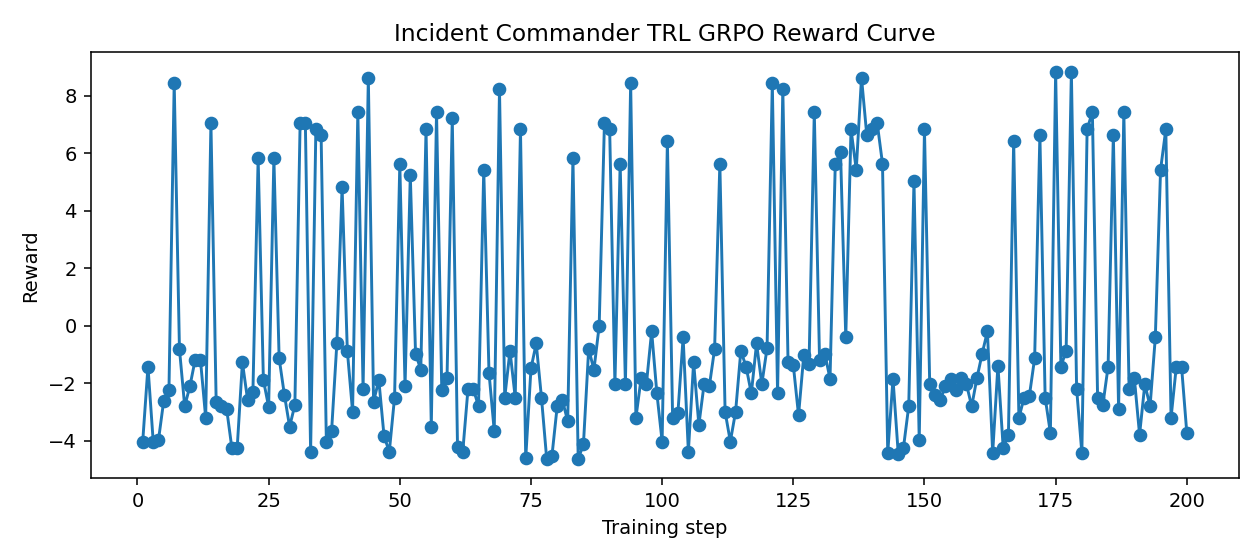

=== Loss Curve ===


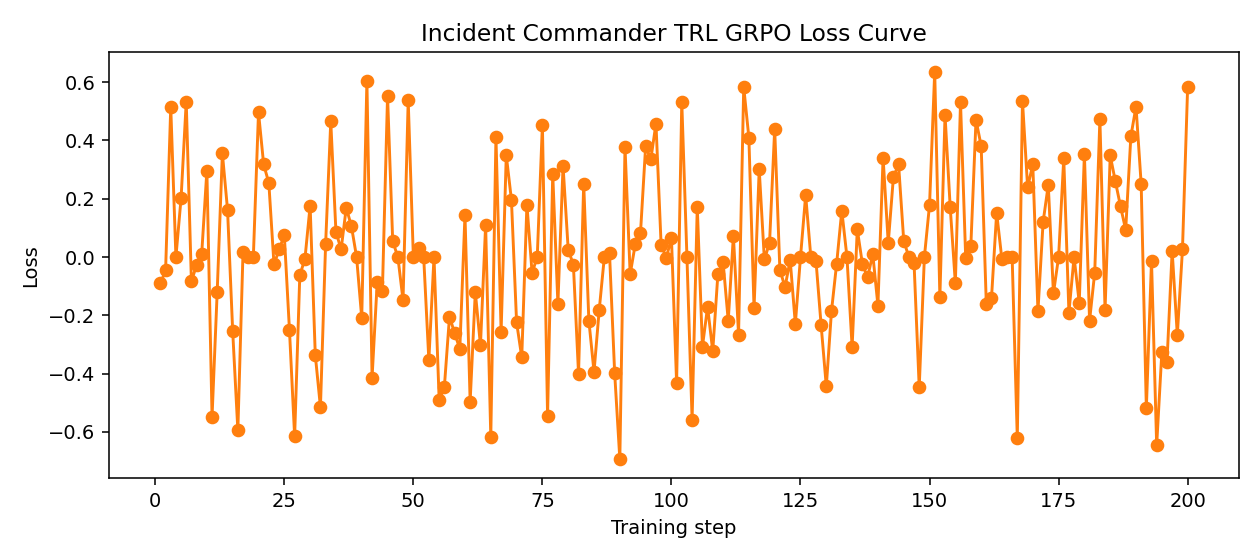

In [9]:
from pathlib import Path
from IPython.display import Image, display

reward_png = Path('outputs/evals/trl_grpo/trl_grpo_reward_curve.png')
loss_png   = Path('outputs/evals/trl_grpo/trl_grpo_loss_curve.png')

if reward_png.exists():
    print('=== Reward Curve ===')
    display(Image(filename=str(reward_png)))
else:
    print('Reward curve not found.')

if loss_png.exists():
    print('=== Loss Curve ===')
    display(Image(filename=str(loss_png)))
else:
    print('Loss curve not found.')

## 8. Notes

All artifacts are written to `outputs/evals/trl_grpo/`.
